In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Dropout,
    Flatten,
    Dense
)

C:\Users\sonag\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:

def build_heavy_cnn_deep_ann(input_shape=(28, 28, 1), num_classes=36) -> Sequential:
    """
    Hybrid Architecture combining:
    1. Heavy CNN Feature Extractor (3 Convolutional Blocks)
    2. Deep ANN Classifier (3 Dense Hidden Layers)
    """
    model = Sequential([
        Input(shape=input_shape),

        # =========================================================
        # STAGE 1: HEAVY CNN FEATURE EXTRACTOR
        # =========================================================
        # CNN Block 1: Low-level features (edges, lines)
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # CNN Block 2: Mid-level features (curves, corners)
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # CNN Block 3: High-level features (loops, intersections)
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.3),

        # =========================================================
        # TRANSITION LAYER
        # =========================================================
        Flatten(),

        # =========================================================
        # STAGE 2: DEEP ANN CLASSIFIER (MLP)
        # =========================================================
        # ANN Layer 1: High-capacity representation
        Dense(512, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),

        # ANN Layer 2: Feature abstraction
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        # ANN Layer 3: Decision refinement
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        # Final Output Layer (Softmax for 36 classes)
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

if __name__ == "__main__":
    model = build_heavy_cnn_deep_ann()
    model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 28, 28, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 14, 14, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 7, 7, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 3, 3, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 512)                 │           2,0

 Total params: 902,916 (3.44 MB)

 Trainable params: 900,484 (3.44 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [3]:
import os
import numpy as np
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Ensure directory exists
os.makedirs("models", exist_ok=True)

# 1. Load Preprocessed Data
train_data = np.load("numpyfiles/train_data.npy")
train_labels = np.load("numpyfiles/train_labels.npy")
test_data = np.load("numpyfiles/test_data.npy")
test_labels = np.load("numpyfiles/test_labels.npy")

In [4]:
# 2. Build Hybrid Model
model = build_heavy_cnn_deep_ann(input_shape=(28, 28, 1), num_classes=36)

In [5]:
# 3. Callbacks
checkpoint = ModelCheckpoint(
    filepath="models/best_val_loss_model.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1
)

lr_reducer = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [6]:
# 4. Train Model
history = model.fit(
    train_data,
    train_labels,
    validation_data=(test_data, test_labels),
    epochs=15,
    batch_size=256,
    callbacks=[checkpoint, lr_reducer, early_stop]
)

Epoch 1/15
1383/1383 ━━━━━━━━━━━━━━━━━━━━ 0s 972ms/step - accuracy: 0.7824 - loss: 0.8249
Epoch 1: val_loss improved from None to 0.09822, saving model to models/best_val_loss_model.weights.h5

Epoch 1: finished saving model to models/best_val_loss_model.weights.h5
1383/1383 ━━━━━━━━━━━━━━━━━━━━ 1454s 1s/step - accuracy: 0.8963 - loss: 0.3736 - val_accuracy: 0.9720 - val_loss: 0.0982 - learning_rate: 0.0010
Epoch 2/15
1383/1383 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9600 - loss: 0.1372
Epoch 2: val_loss improved from 0.09822 to 0.08113, saving model to models/best_val_loss_model.weights.h5

Epoch 2: finished saving model to models/best_val_loss_model.weights.h5
1383/1383 ━━━━━━━━━━━━━━━━━━━━ 1618s 1s/step - accuracy: 0.9636 - loss: 0.1263 - val_accuracy: 0.9775 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 3/15
1383/1383 ━━━━━━━━━━━━━━━━━━━━ 0s 963ms/step - accuracy: 0.9702 - loss: 0.1019
Epoch 3: val_loss improved from 0.08113 to 0.05996, saving model to models/best_val_loss

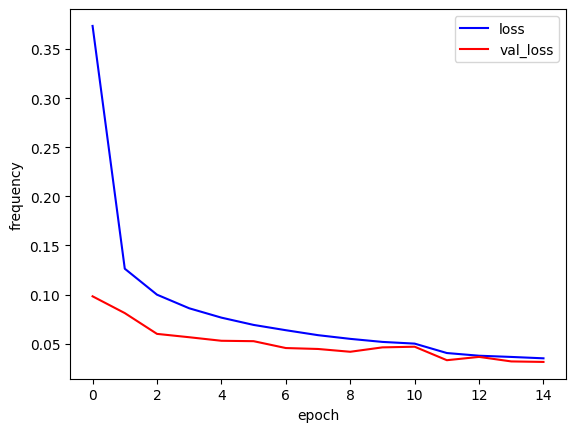

In [7]:
from matplotlib import pyplot as plt
plt.plot(history.history["loss"], 'b', label="loss")
plt.plot(history.history["val_loss"], 'r', label="val_loss")
plt.xlabel("epoch")
plt.ylabel("frequency")
plt.legend()
plt.show()

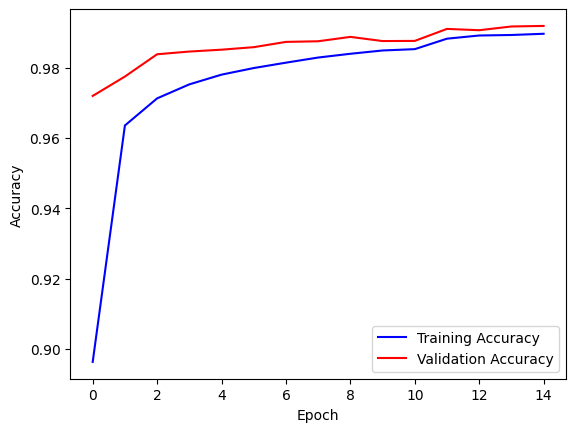

In [8]:
from matplotlib import pyplot as plt
plt.plot(history.history["accuracy"], 'b', label="Training Accuracy")
plt.plot(history.history["val_accuracy"], 'r', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [9]:
# 5. Evaluate
model.load_weights("models/best_val_loss_model.weights.h5")
loss, acc = model.evaluate(test_data, test_labels)
print(f"Final Test Accuracy: {acc * 100:.2f}% | Test Loss: {loss:.4f}")

2766/2766 ━━━━━━━━━━━━━━━━━━━━ 36s 13ms/step - accuracy: 0.9919 - loss: 0.0314
Final Test Accuracy: 99.19% | Test Loss: 0.0314


In [10]:
model.save("models/handwritten_character_model.keras")